# From a measurement to a calibrated potential

This notebook walks the **production path**: an EXFOR-shaped measurement —
reported in its own units, with statistical *and* systematic errors — is turned
into an `ElasticDifferentialXSObservation` via `from_measurement`, its reported
systematics are composed as explicit covariance terms, and a small optical
potential is calibrated against it.

The unit contract, up front:

- **dimensionful** errors (statistical, absolute offset) are divided by the unit
  normalization `norm` when the observation is built;
- the **fractional** normalization error is dimensionless and passes through
  untouched;
- `norm` itself is retained as `obs.norm` for provenance.


In [1]:
from types import SimpleNamespace

import corner
import jitr
import matplotlib.pyplot as plt
import numpy as np
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from scipy import stats

import rxmc
from rxmc.params import Parameter

rng = np.random.default_rng(11)

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31


## The reaction and optical model

In [2]:
Ca40 = (40, 20)
neutron = (1, 0)
E_lab = 14.1

rxn = jitr.reactions.ElasticReaction(target=Ca40, projectile=neutron)

mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def central_potential(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) + (
        4j * ad * Wd
    ) * woods_saxon_prime_safe(r, Rd, ad)


def spin_orbit_potential(r, Vso, Wso, Rso, aso):
    return (Vso + 1j * Wso) * mso**2 * thomas_safe(r, Rso, aso)


R = 1.2 * 40 ** (1 / 3)
fixed_spin_orbit = (6.0, -3, R, 0.45)


def extract_params(ws, *x):
    Vv, Wv, Rv, av, Wd, Rd, ad = x
    central_params = (Vv, Wv, Rv, av, Wd, Rd, ad)
    return central_params, fixed_spin_orbit


params = [
    Parameter("Vv", unit="MeV"),
    Parameter("Wv", unit="MeV"),
    Parameter("Rv", unit="fm"),
    Parameter("av", unit="fm"),
    Parameter("Wd", unit="MeV"),
    Parameter("Rd", unit="fm"),
    Parameter("ad", unit="fm"),
]

omp = rxmc.elastic_diffxs_model.ElasticDifferentialXSModel(
    "dXS/dA",
    interaction_central=central_potential,
    interaction_spin_orbit=spin_orbit_potential,
    calculate_interaction_from_params=extract_params,
    params=params,
    model_name="measurement_demo",
)

## A measurement, as EXFOR reports it

EXFOR entries report cross sections in their own units — here **mb/sr** — with a
statistical error column and, often, scalar systematic errors: a *fractional*
normalization uncertainty (e.g. from the flux calibration) and an *absolute*
offset uncertainty (e.g. from background subtraction), in the same units as the
data.  We mock up such a measurement (`exfor_tools.Distribution` carries exactly
these fields) from a known truth so we can check the calibration at the end.


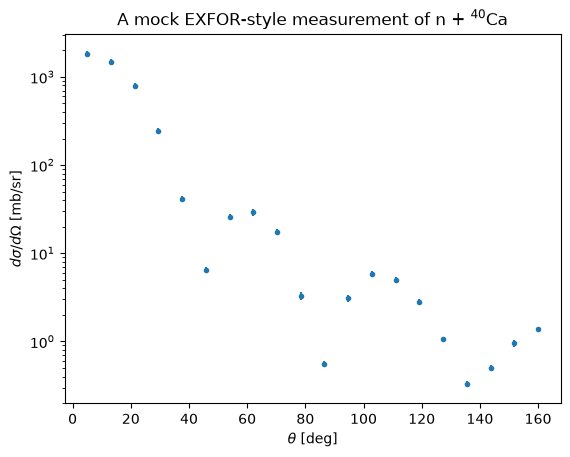

In [3]:
angles_deg = np.linspace(5.0, 160.0, 20)
true_params = np.array(
    [48.0, 3.5, 1.1 * 40 ** (1 / 3), 0.7, 21, 1.2 * 40 ** (1 / 3), 0.5]
)

template_obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
    x=angles_deg,
    y=np.ones_like(angles_deg, dtype=float),
    Elab=E_lab,
    reaction=rxn,
    quantity="dXS/dA",
    measurement_quantity="dXS/dA",
    y_units="barn / steradian",
    dataset_label="template",
)

y_true_b = omp.evaluate(template_obs, *true_params)  # b/sr
y_true_mb = y_true_b * 1000.0  # the measurement is reported in mb/sr

stat_err_mb = 0.08 * np.maximum(y_true_mb, 1e-1)
y_mb = np.clip(y_true_mb + rng.normal(scale=stat_err_mb), 1e-3, None)

measurement = SimpleNamespace(
    x=angles_deg,  # degrees
    y=y_mb,  # mb/sr
    Einc=E_lab,
    quantity="dXS/dA",
    y_units="mb/sr",
    statistical_err=stat_err_mb,  # mb/sr
    systematic_norm_err=0.04,  # fractional (dimensionless)
    systematic_offset_err=2.0,  # absolute, mb/sr
    subentry="toy-subentry",
)

plt.errorbar(
    measurement.x, measurement.y, measurement.statistical_err, ls="none", marker="."
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [mb/sr]")
plt.yscale("log")
plt.title("A mock EXFOR-style measurement of n + $^{40}$Ca");

## `from_measurement` keeps the systematics as inert metadata

The observation stores its data in internal units (b/sr).  Everything
**dimensionful** — `y`, the statistical error, the absolute offset error — is
divided by `obs.norm` (here $10^3$, mb $\to$ b); the **fractional** normalization
error is dimensionless and untouched.  The systematics are *metadata*: they do
not enter any covariance until you ask.


In [4]:
obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation.from_measurement(
    measurement=measurement,
    reaction=rxn,
    quantity="dXS/dA",
)

print(f"unit normalization      obs.norm = {obs.norm}")
print(f"fractional norm error   {obs.y_sys_err_normalization}  (passed through)")
print(f"absolute offset error   {obs.y_sys_err_offset} b/sr  (= 2.0 mb/sr / norm)")
print(f"y[0]: measurement {measurement.y[0]:.2f} mb/sr -> stored {obs.y[0]:.5f} b/sr")

unit normalization      obs.norm = 1000.0
fractional norm error   0.04  (passed through)
absolute offset error   0.002 b/sr  (= 2.0 mb/sr / norm)
y[0]: measurement 1834.19 mb/sr -> stored 1.83419 b/sr


## Nothing is folded in silently — systematics are explicit terms

By design there is **no compatibility path that re-folds systematics into the
covariance automatically**: the default constraint covariance is the statistical
diagonal only.  `obs.systematic_terms(support)` turns the retained metadata into
fixed rank-one terms — the absolute offset mode
$\Sigma \mathrel{+}= \omega\omega^T$ and the prediction-scaled normalization mode
$\Sigma \mathrel{+}= \eta^2\, y_m y_m^T$ — which you pass in as `extra_terms`.


['RankOneTerm', 'RankOneTerm']


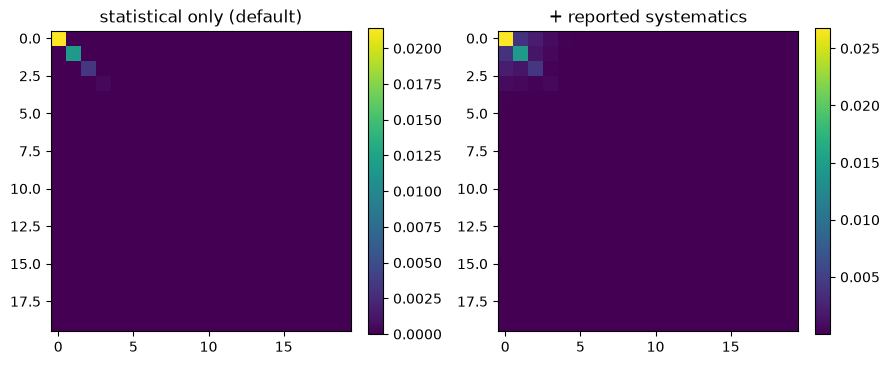

In [5]:
(support,) = rxmc.covariance.stacked_supports([obs])
terms = obs.systematic_terms(support)
print([type(t).__name__ for t in terms])

constraint_stat = rxmc.constraint.Constraint([obs], omp)
constraint = rxmc.constraint.Constraint([obs], omp, extra_terms=terms)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for a, (c, title) in zip(
    axes,
    [
        (constraint_stat, "statistical only (default)"),
        (constraint, "+ reported systematics"),
    ],
):
    im = a.imshow(c.covariance_matrix(true_params), cmap="viridis")
    a.set_title(title)
    fig.colorbar(im, ax=a, fraction=0.046)
fig.tight_layout()

## Guardrail: a measurement with no statistical error

EXFOR subentries that report only a systematic error come back with
`statistical_err = 0`.  The old pipeline would let that propagate and crash deep
inside the sampler; now the `Constraint` fails fast, names the dataset, and
suggests the remedies.


In [6]:
measurement_nostat = SimpleNamespace(**{**vars(measurement)})
measurement_nostat.statistical_err = np.zeros_like(y_mb)
measurement_nostat.subentry = "toy-subentry-nostat"

obs_nostat = (
    rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation.from_measurement(
        measurement=measurement_nostat,
        reaction=rxn,
        quantity="dXS/dA",
    )
)

try:
    rxmc.constraint.Constraint([obs_nostat], omp)
except ValueError as err:
    print(err)

Constraint covariance over [toy-subentry-nostat] is singular (Cholesky factorization failed). The covariance diagonal is zero on rows belonging to ['toy-subentry-nostat']: these datasets report zero statistical error and no other covariance term covers their points. Remedies: pass the dataset's reported systematics as terms (extra_terms=[*obs.systematic_terms(support)], with supports from rxmc.covariance.stacked_supports(observations)), add a noise_term or DenseTerm covering those points, or compose the full covariance explicitly with include_statistical_term=False.


As the message says: supply the dataset's reported systematics as terms, add a
`noise_term` (a free noise nuisance), or compose the covariance explicitly.  Note
that the offset and normalization modes alone are rank-two, so a dataset with
*only* systematic errors still needs a diagonal contribution (a noise term or an
error floor) to make $\Sigma$ positive definite.  Our measurement has statistical
errors, so we proceed.


## Calibrate

In [7]:
evidence = rxmc.evidence.Evidence(constraints=[constraint])

prior_mean = np.array(
    [50.0, 3, 1.2 * 40 ** (1 / 3), 0.65, 18, 1.2 * 40 ** (1 / 3), 0.65]
)
prior_cov = np.diag([7, 7, 0.2, 0.2, 10, 0.2, 0.2]) ** 2
prior = stats.multivariate_normal(mean=prior_mean, cov=prior_cov)

walker = rxmc.walker.Walker(
    model_sampler=rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=omp.params,
        prior=prior,
        starting_location=prior_mean,
        initial_proposal_cov=prior_cov / 100,
    ),
    evidence=evidence,
    rng=np.random.default_rng(7),
)

In [8]:
%%time
walker.walk(n_steps=8000, burnin=1000, batch_size=1000, verbose=False)
samples = walker.model_sampler.chain
walker.model_sampler.overall_acceptance_fraction()

CPU times: user 16.7 s, sys: 1.4 ms, total: 16.7 s
Wall time: 16.7 s


0.206125

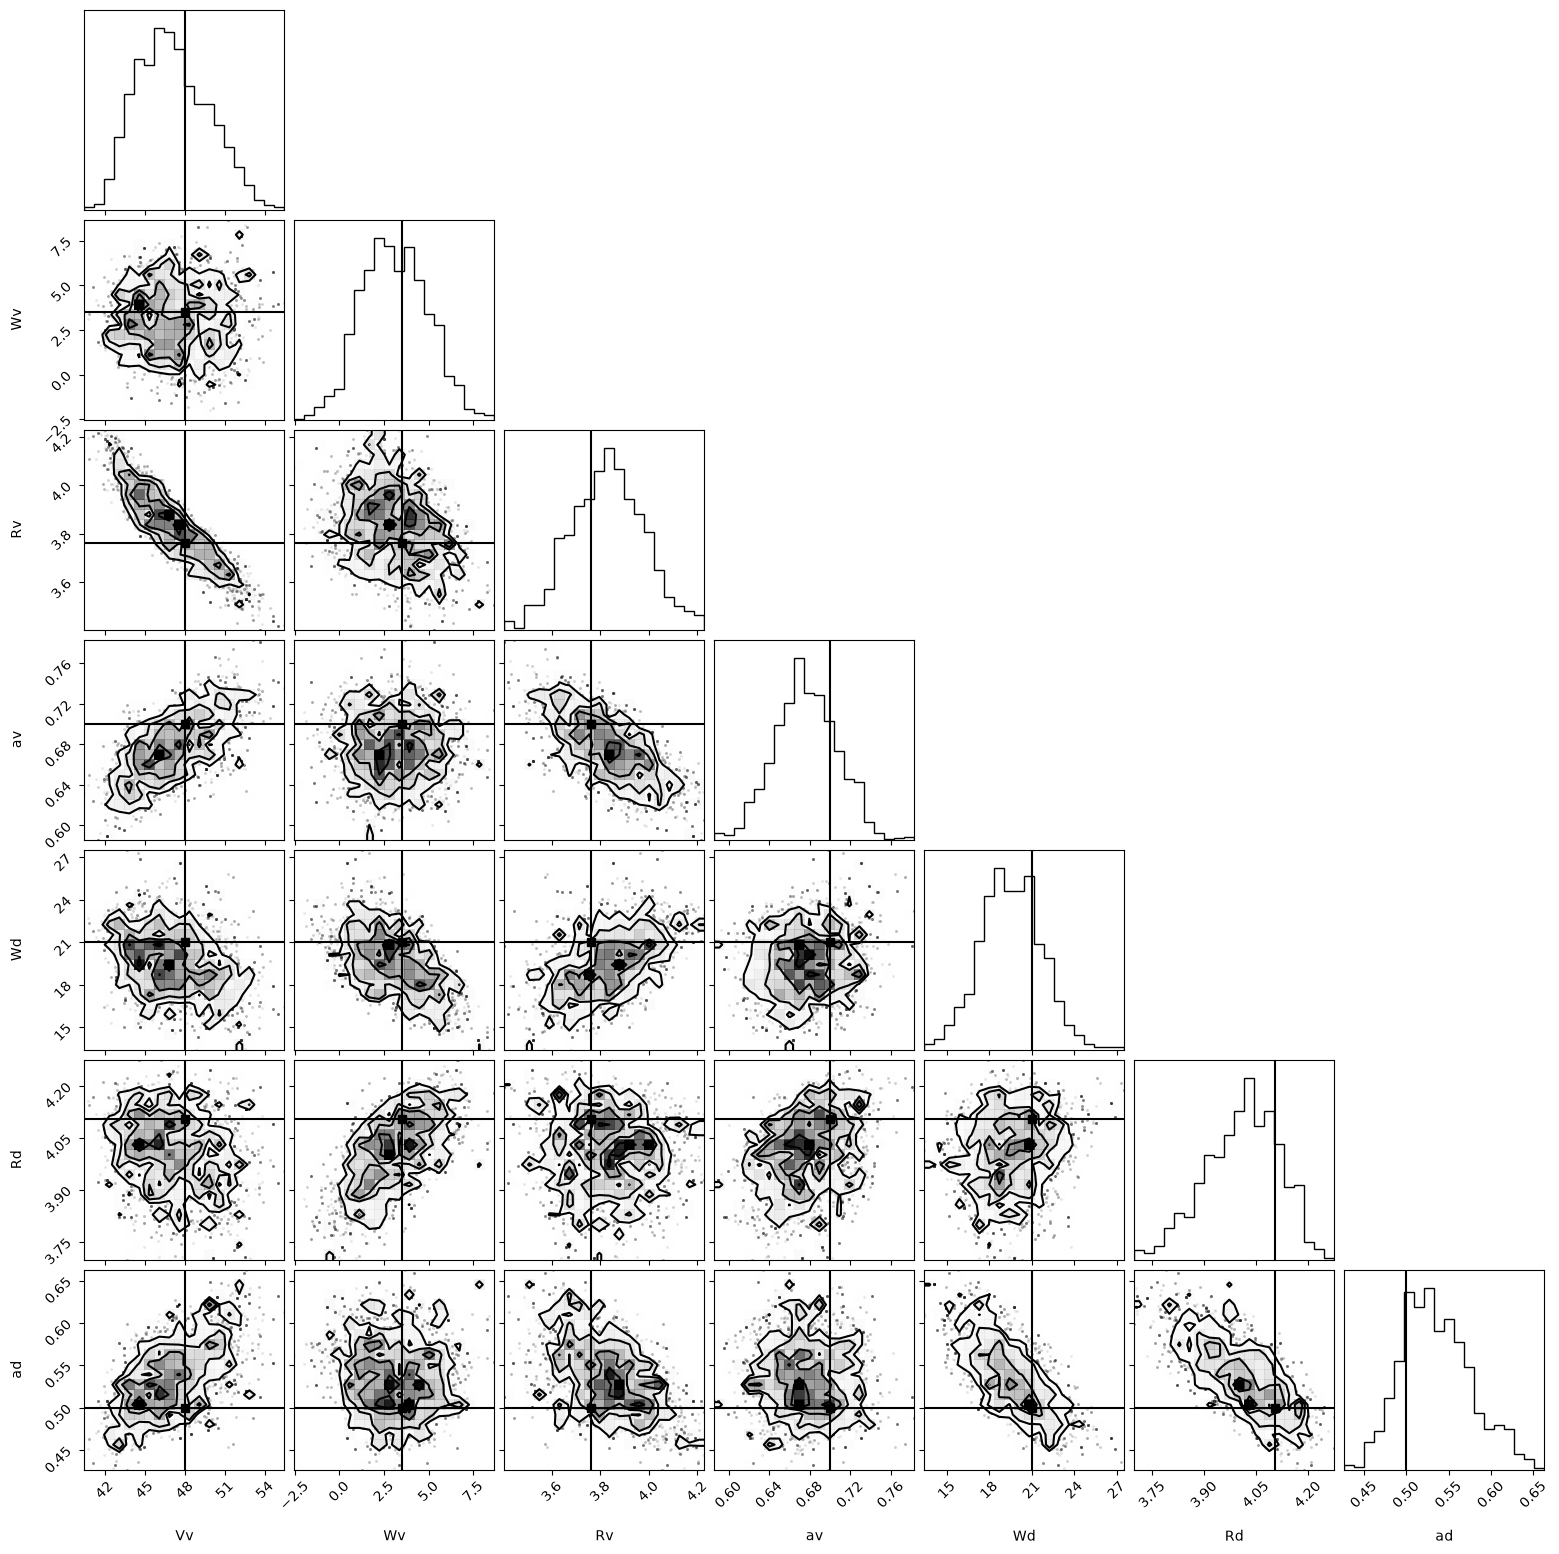

In [9]:
fig = corner.corner(
    samples,
    labels=[p.name for p in omp.params],
    truths=true_params,
    truth_color="k",
)

## Predictive check

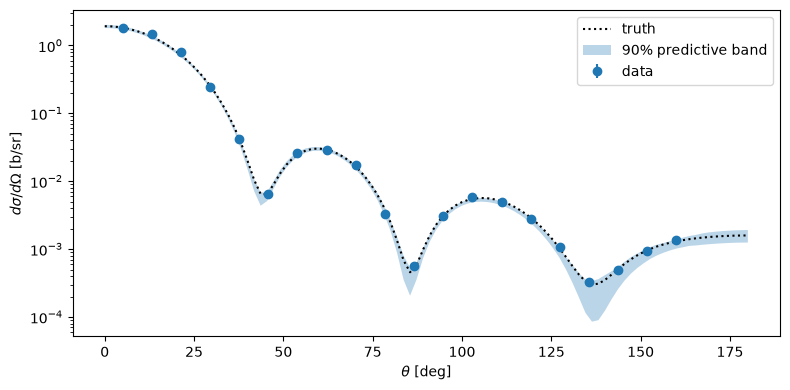

In [10]:
draw_indices = np.linspace(0, samples.shape[0] - 1, 60, dtype=int)
y_draws = np.array(
    [omp.visualizable_model_prediction(obs, *d) for d in samples[draw_indices]]
)
y_low, y_high = np.percentile(y_draws, [5, 95], axis=0)

angles_plot = np.rad2deg(obs.visualization_workspace.angles)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.errorbar(
    np.rad2deg(obs.x), obs.y, yerr=obs.y_stat_err, ls="none", marker="o", label="data"
)
ax.plot(
    angles_plot,
    omp.visualizable_model_prediction(obs, *true_params),
    "k:",
    label="truth",
)
ax.fill_between(angles_plot, y_low, y_high, alpha=0.3, label="90% predictive band")
ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma/d\Omega$ [b/sr]")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()

## Takeaways

- **The unit contract**: `from_measurement` divides everything dimensionful
  (data, statistical error, absolute offset error) by `obs.norm` and passes the
  fractional normalization error through untouched.  `obs.norm` is retained, so
  you can always convert back.
- **Systematics are opt-in**: they ride along as metadata and become covariance
  terms only via `obs.systematic_terms(support)` passed to
  `Constraint(extra_terms=...)` — nothing correlated is hidden in a default.
- **The guardrail**: a dataset contributing zero variance fails at construction
  with a message naming the subentry, not with an opaque `LinAlgError` mid-chain.
- To adapt to production: replace the `SimpleNamespace` with an
  `exfor_tools.Distribution` — the fields are the same.
